Biometrich Technologies and Behavioural Security
# **<center>Tutorial 3 - Fingerprint Liveness Detection</center>**

## Step 1: Load data and packages in your VM

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import time
from skimage import feature
from IPython.display import HTML, display
from IPython.display import clear_output

#Function for progress bar.
def progress(value, max=100):
    return HTML("""<progress value='{value}' max='{max}', style='width: 100%'>
            {value}
        </progress>""".format(value=value, max=max))

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id': '1dOIBPgvjVRkBX_8wkkUNHFxuHmT2vEOg'})   # replace the id with id of file you want to access
downloaded.GetContentFile('dataset_esercitazione.zip')        # replace the file name with your file
!unzip dataset_esercitazione

clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


## Step 2: Define class LocalBinaryPatterns

In [ ]:
np.set_printoptions(suppress=True)
class LocalBinaryPatterns:
	def __init__(self, numPoints, radius):
		# store the number of points and radius
		self.numPoints = numPoints
		self.radius = radius

	def describe(self, image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, self.numPoints, self.radius, method="uniform")
		(hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, self.numPoints + 3), range=(0, self.numPoints + 2))

		# normalize the histogram
		hist = hist.astype("float")
		#eps is a small float added to avoid dividing by zero
		hist /= (hist.sum() + eps)

		# return the histogram of Local Binary Patterns
		return hist

## Step 3: Feature Extraction

As before, we have to extract all LBP codes from our fingerprint dataset. Once again, we'll compute them only for *Train* sub-folder. In each row of **data** variable, we store a different *histogram*, derived from LBP image and composed this time by 26, while in **labels** variable, we store:

*   **1** if the fingerprint image comes from <font color=green>**Live**</font> sub-directory
*   **0** if the fingerprint image comes from <font color=red>**Fake**</font> sub-directory

In [ ]:
#set the number of points and the radius dimension
desc = LocalBinaryPatterns(24, 10)
#Initialize 2 lists to create our training set
data = []
labels = []

In [ ]:
'''
    For the given path, get the List of all files in the directory tree
'''
def getListOfFiles(dirName):
    # create a list of file and sub directories
    # names in the given directory
    listOfFile = os.listdir(dirName)
    allFiles = list()
    # Iterate over all the entries
    for entry in listOfFile:
        # Create full path
        fullPath = os.path.join(dirName, entry)
        # If entry is a directory then get the list of files in this directory
        if os.path.isdir(fullPath):
            allFiles = allFiles + getListOfFiles(fullPath)
        else:
            allFiles.append(fullPath)

    return allFiles

In [ ]:
path = "/content/dataset_GB/Train/"
train_images = getListOfFiles(path)

print('Extracting LBP Code (1 minute)...')
out = display(progress(0, len(train_images)*2), display_id=True)
kk=0
t = time.time()

for im in train_images:
    if 'Live/007_8_0.png' in im:
      continue
    gray = cv2.imread(im,0)
    hist = desc.describe(gray)

    data.append(hist)
    kk=kk+1
    out.update(progress(kk, len(train_images)))

    if "Live" in im:
        labels.append(1)
    elif "Fake" in im:
        labels.append(0)

elapsed = 'Process completed! Elapsed time: %.2f s' %(time.time() - t)
print(elapsed)

Extracting LBP Code (10 minutes)...


Process completed! Elapsed time: 37.11 s


In [ ]:
print(np.shape(data))
print(np.shape(labels))

(299, 26)
(299,)


## Step 4: Building Neural Network

https://github.com/google-research/tuning_playbook#choosing-a-model-architecture

Keras is a simple tool for constructing a neural network. It is a high-level framework based on tensorflow, theano or cntk backends.
In our dataset, the input is of 26 values and output is of 1 values. So the input and output layer is of 26 and 1 dimensions respectively. The following steps will define the **neural network architecture**.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

***Sequential*** specifies to keras that we are creating model sequentially
and the output of each layer we add is input to the next layer we specify.

In [ ]:
model = Sequential()

***model.add*** is used to add a layer to our neural network. We need to specify as an argument what type of layer we want. The Dense is used to specify the fully connected layer. The arguments of Dense are output dimension which is 16 in the first case, input dimension which is 26 for input dimension and the  activation function to be used which is relu in this case.

In [ ]:
model.add(Dense(16, input_dim=26, activation='relu'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The second layer is similar, we don't need to specify input dimension as we have defined the model to be sequential so keras will automatically consider input dimension to be same as the output of last layer i.e 16. In the third layer(output layer) the output dimension is 1.

In [ ]:
model.add(Dense(12, activation='relu'))
model.add(Dense(6, activation='relu'))

The output layer takes different
activation functions and for the case of binary classification, it is sigmoid.

In [ ]:
model.add(Dense(1, activation='sigmoid'))

Now we need to specify the loss function and the optimizer.
It is done using compile function in keras.
Here loss is cross entropy loss, binary_crossentropy specifies
that we have 2 classes. The optimizer is Adam. Metrics is used to specify the way we want to judge the performance of our neural network. Here we have specified it to accuracy, we can also check the model’s performance on validation set(in this case with X_test and y_test)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

## Step 5: Training model

Usually, the dataset is very big and we cannot fit complete data at once so we use batch size. This divides our data into batches each of size equal to batch_size. Now only this number of samples will be loaded into memory and processed. Once we are done with one batch it is flushed from memory and the next batch will be processed.

In [ ]:
from sklearn.model_selection import train_test_split
#the validation set will consist of 10% of the data
X_train,X_val,y_train,y_val = train_test_split(np.array(data),np.array(labels),test_size = 0.1)

Training step is simple in keras. ***model.fit*** is used to train it.

In [ ]:
history = model.fit(X_train,y_train,
              batch_size=10,
              epochs=500,
              validation_data=(X_val, y_val),
              shuffle=True)

Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6986 - loss: 0.6754 - val_accuracy: 0.6667 - val_loss: 0.6643
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6665 - loss: 0.6611 - val_accuracy: 0.6667 - val_loss: 0.6508
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6955 - loss: 0.6375 - val_accuracy: 0.6667 - val_loss: 0.6396
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6638 - loss: 0.6381 - val_accuracy: 0.6667 - val_loss: 0.6331
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6591 - loss: 0.6336 - val_accuracy: 0.6667 - val_loss: 0.6272
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6697 - loss: 0.6202 - val_accuracy: 0.6667 - val_loss: 0.6216
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6815 - loss: 0.6087 - val_accuracy: 0.6667 - val_loss: 0.6158
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6282 - loss: 0.6354 - val_accuracy: 0.6667 - 

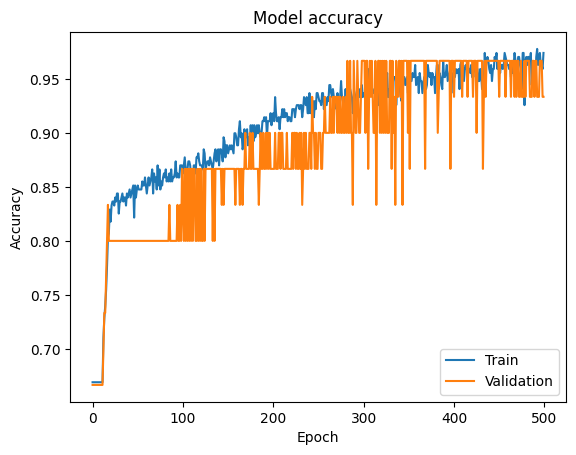

In [ ]:
#Our model is working fine. Now we will visualize training and validation losses and accuracies.

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

##Step 6: Create the test set

In [ ]:
X_ts = []
y_ts = []
path = "/content/dataset_GB/Test/"
test_images = getListOfFiles(path)

print('Extracting LBP Code for Test folder...')
out = display(progress(0, len(train_images)*2), display_id=True)
kk=0
t = time.time()

for im in test_images:
    gray = cv2.imread(im,0)
    hist = desc.describe(gray)

    X_ts.append(hist)
    kk=kk+1
    out.update(progress(kk, len(train_images)))

    if "Live" in im:
        y_ts.append(1)
    elif "Fake" in im:
        y_ts.append(0)
X_ts = np.array(X_ts)
y_ts = np.array(y_ts)

elapsed = 'Process completed! Elapsed time: %.2f s' %(time.time() - t)
print(elapsed)

Extracting LBP Code for Test folder...


Process completed! Elapsed time: 11.41 s


##Step 7: Classification with our model

In [ ]:
#y_pred = model.predict_classes(X_ts) # Before tensorflow 2.6
scr = model.predict(X_ts) # We extract the score for each class ...
y_pred = np.rint(scr)     # ... and then we round it to the nearest integer
from sklearn.metrics import accuracy_score
acc='Total Accuracy: %.2f %%' % (accuracy_score(y_ts, y_pred)*100)
print(acc)
score = model.evaluate(X_ts, y_ts, batch_size=250)
print(score)

Total Accuracy: 87.00 %


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


2/2 [==============================] - 0s 8ms/step - loss: 0.3278 - accuracy: 0.8700
[0.32779061794281006, 0.8700000047683716]


##Step 8: Repeat step 5 and step 7 and check if the result changes